In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from control import *

import sys
sys.path.append('simulation/model')
from motor_params import *

In [36]:
# DC Motor Transfer Function
# Input: voltage U [V]
# Output: angular velocity omega [rad/s]

num = [Kt]
den = [J*L, J*R + B*L, B*R + Ke*Kt]

motor_tf = tf(num, den, name='DC Motor')
print(motor_tf)

<TransferFunction>: DC Motor
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             0.1
  --------------------------
  5e-06 s^2 + 0.02 s + 0.012


In [37]:
# Poles of the transfer function

poles = motor_tf.poles()
print(f'Poles: {poles}')
print(f'Time constants: {-1/poles.real} s')

Poles: [-3.99949992e+03+0.j -6.00075021e-01+0.j]
Time constants: [2.50031259e-04 1.66645830e+00] s


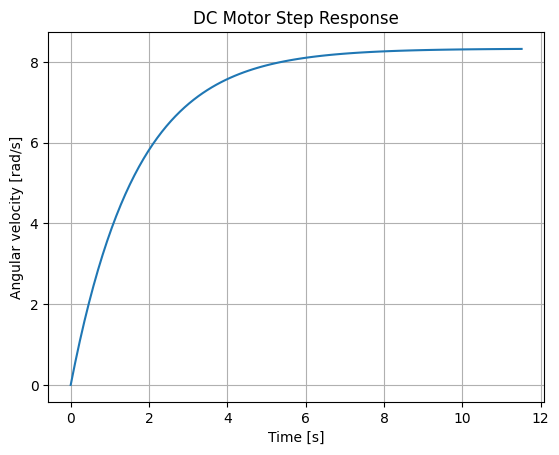

In [38]:
# Step response - reaction to voltage step input
t, y = step_response(motor_tf)

plt.plot(t, y)
plt.xlabel('Time [s]')
plt.ylabel('Angular velocity [rad/s]')
plt.title('DC Motor Step Response')
plt.grid(True)
plt.show()

In [39]:
# Static gain - steady state velocity for unit voltage step
K_static = Kt / (B*R + Ke*Kt)
print(f'Static gain: {K_static:.3f} rad/s/V')

# Dominant time constant
tau = (J*R + B*L) / (B*R + Ke*Kt)
print(f'Time constant: {tau:.3f} s')

Static gain: 8.333 rad/s/V
Time constant: 1.667 s


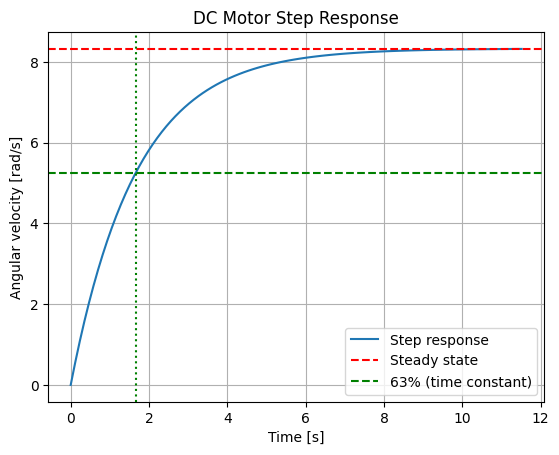

In [40]:
t, y = step_response(motor_tf)

plt.plot(t, y, label='Step response')
plt.axhline(y=K_static, color='r', linestyle='--', label='Steady state')
plt.axhline(y=0.63*K_static, color='g', linestyle='--', label='63% (time constant)')
plt.axvline(x=tau, color='g', linestyle=':')
plt.xlabel('Time [s]')
plt.ylabel('Angular velocity [rad/s]')
plt.title('DC Motor Step Response')
plt.legend()
plt.grid(True)
plt.show()

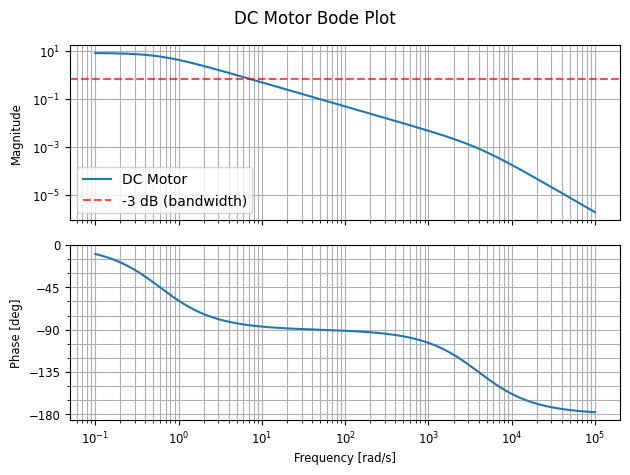

In [42]:
# Bode plot of motor

response = frequency_response(motor_tf)
response.plot()
fig = plt.gcf()
axes = fig.get_axes()
ax_mag = axes[0]
ax_phase = axes[1]

ax_mag.axhline(10**(-3/20), color='red', linestyle='--', alpha=0.7, label='-3 dB (bandwidth)') # -3db
ax_mag.legend()
plt.suptitle('DC Motor Bode Plot')
plt.show()